# Market regime detection using Statistical and ML based approaches

## Introduction

金融市场的微观结构行为会随时间发生变化，受到各种外部和内部因素的影响。这可能导致不同的市场制度（market regimes），即市场条件持续相似的时期。金融市场参与者旨在检测这些市场制度及其转变，以应对潜在风险并做出更明智的投资决策。

目前存在多种划分市场制度的方法。许多从业者或研究人员将市场分为“繁荣”（boom）或“萧条”（bust）市场；另一些人则根据波动率进行分类，例如高波动、低波动和中波动制度。还有一种方法是根据投资者的偏好，将市场状况分为“风险偏好”（risk on）或“风险厌恶”（risk off）状态。

识别市场制度是一个无监督学习过程，有多种技术可以帮助基于历史市场数据确定当前市场状态。这些技术包括统计学方法，如向量自回归（VAR）模型和隐马尔可夫模型（HMM）；以及机器学习方法，如聚类模型（例如 K-means、层次聚类和高斯混合模型（GMM））。

在本篇的范围内，我们的目标是利用多种统计和机器学习模型（包括高斯 HMM、K-means 聚类和高斯混合模型），识别标普 500 指数的“正常（增长）”或“崩盘（快速下跌）”市场状态。此外，我们将基于识别出的市场状态构建一个简单的投资策略，并将其与同一资产在整个分析期内的基础“买入并持有”策略进行对比。

## Data Ingestion and Engineering

在本篇中，我们将接入标普 500 指数期货合约（ESc1）的数据。我们之所以选择对期货而非指数本身或 ETF 进行分析和策略构建，是因为期货合约全天候均可交易，而 ETF 则受限于证券交易所的交易时间。

#### Install and import packages

首先，我们安装并导入必要的软件包。其他必需的软件包也已按如下所示进行了适当安装：

In [18]:
import numpy as np
# from sklearn.cluster import KMeans
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import warnings
import math

warnings.filterwarnings('ignore')

## Data Ingestion and Engineering

在本节中，我们使用 ESc1（标普 500 指数期货） 从 1997年1月1日到2022年12月31日 的历史价格，随后进行数据预处理，以便将其输入到市场制度检测算法中。

以下是关于如何请求指定标的历史成交价并将其绘制成图表的方法。

In [19]:
# 如果 yfinance 下载出现 rate limit error，修改代理设置，并运行以下代码
# 详情见 https://blog.csdn.net/m0_50837851/article/details/146198595

# import os
# proxy = 'http://127.0.0.1:7897'	# 代理设置，此处修改
# os.environ['HTTP_PROXY'] = proxy 
# os.environ['HTTPS_PROXY'] = proxy 

In [20]:
import yfinance as yf

trading_instrument = "ES=F"  # Yahoo Finance symbol for E-mini S&P 500 futures, same as ESc1
start_date = "1997-01-01"
end_date = "2023-02-01"

df = yf.download(trading_instrument, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [21]:
prices = df['Close'][trading_instrument].to_frame()
prices.columns.name = trading_instrument
prices

ES=F,ES=F
Date,
2000-09-18,1467.50
2000-09-19,1478.50
2000-09-20,1469.50
2000-09-21,1469.50
2000-09-22,1468.50
...,...
2023-01-25,4032.00
2023-01-26,4075.50
2023-01-27,4084.25


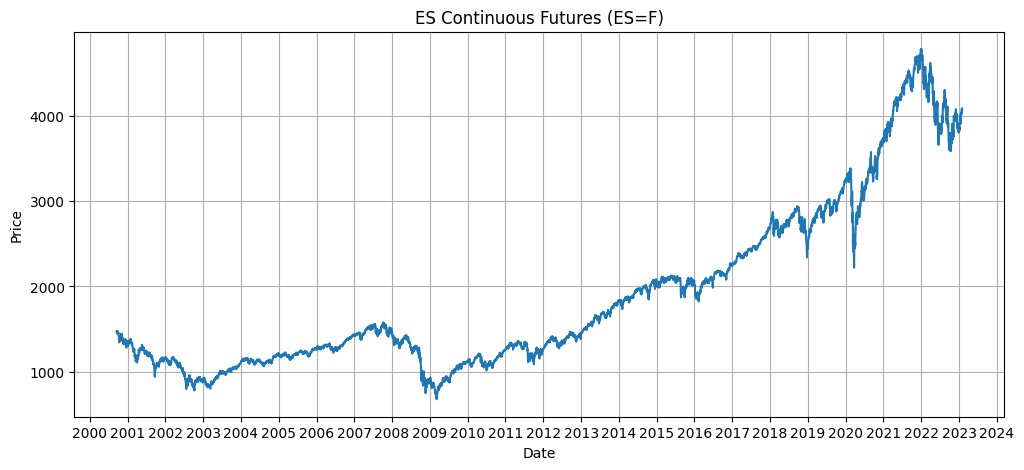

In [34]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))
plt.plot(prices.index, prices[trading_instrument])
plt.title("ES Continuous Futures (ES=F)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1)) 

plt.show()

在观察价格走势后，我们可以在分析期内确定几次市场崩盘。其中，值得关注的有 2007-2009 年的金融危机、2020 年 2 月的 COVID 崩盘，以及从 2022 年初开始的最新的衰退期。本市场制度检测原型的目标，就是识别这些以及任何其他存在的崩盘时期。

在进入具体代码前，我们先为市场制度检测模型准备输入数据。首先，我们从原始数据中衍生出一个新特征：历史收盘价 7 日移动平均线的对数收益率。

使用对数收益率（Log Returns）而非简单收益率（Simple Returns）的优势在于：对数收益率在时间维度上具有对称性和可加性，这使得它们在跨不同时间段进行比较时成为更好的衡量标准。此外，对数收益率对当前价格进行了归一化处理，不受资产价格绝对水平的影响。因此，在比较不同标的的表现时，对数收益率也提供了更好的衡量尺度。

之所以选择对价格的移动平均线（Moving Average）而非价格本身计算对数收益率，是因为移动平均线有助于过滤掉时间序列中的随机噪声，并平滑掉短期的价格波动。这使得模型能够更专注于长期价格走势

下文我们提供了一个名为 prepare_data_for_model_input 的函数，该函数应用了上述方法，并返回一个包含收盘价、移动平均价及其对数收益率的数据框。此外，该函数还将返回一个对数收益率数组，该数组将作为下一节讨论的市场制度检测模型的输入数据。

In [23]:
def prepare_data_for_model_input(prices, ma):
    instrument = prices.columns.name
    
    prices[f'{instrument}_ma'] = prices.rolling(ma).mean()
    prices[f'{instrument}_log_return'] = np.log(prices[f'{instrument}_ma']/prices[f'{instrument}_ma'].shift(1)).dropna()
    prices_clean = prices.dropna()
    
    # 转换为 HMM 要求的形状 (n_samples, 1)
    features = prices_clean[[f'{instrument}_log_return']]
    
    # 依然建议标准化，让模型在优化时数值更稳定
    scaler = StandardScaler()
    features_scaled = pd.DataFrame(
        scaler.fit_transform(features),
        index=features.index,
        columns=features.columns
    )
    
    return prices_clean, features
prices_clean, features = prepare_data_for_model_input(prices, 7)
features

ES=F,ES=F_log_return
Date,
2000-09-27,-0.002025
2000-09-28,-0.000244
2000-09-29,-0.001516
2000-10-02,-0.001297
2000-10-03,-0.002649
...,...
2023-01-25,0.000492
2023-01-26,0.002358
2023-01-27,0.004930


下文我们将调用该函数并展示生成的特征数据。

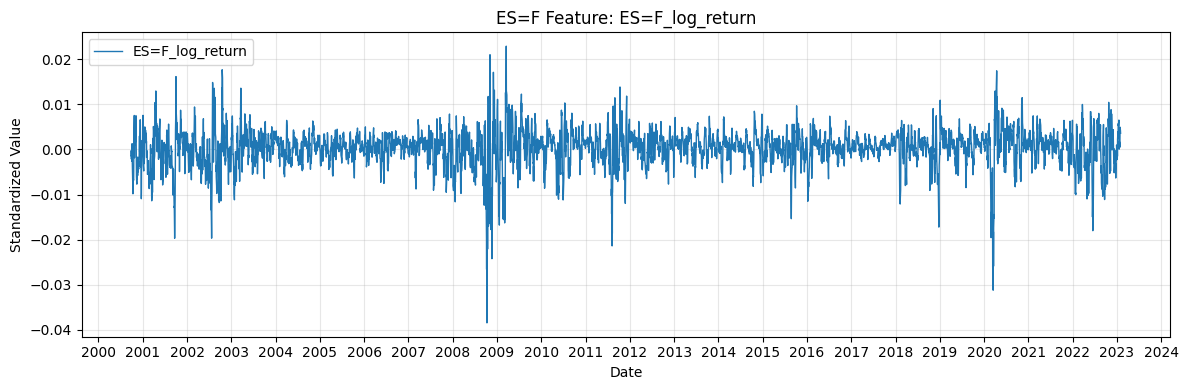

In [35]:
def plot_features(features):
    instrument = features.columns.name
    n_features = features.shape[1]

    fig, axes = plt.subplots(nrows=n_features, ncols=1, figsize=(12, 4 * n_features), sharex=True)
    
    # 如果只有一个特征，axes 不是数组，需要转换一下
    if n_features == 1:
        axes = [axes]
    
    for i, col_name in enumerate(features.columns):
        ax = axes[i]
        ax.plot(features.index, features[col_name], label=col_name, linewidth=1, color=f'C{i}')
        
        ax.set_title(f"{instrument} Feature: {col_name}", fontsize=12)
        ax.set_ylabel("Standardized Value")
        ax.grid(True, alpha=0.3)
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.YearLocator(1)) 
        ax.legend(loc='upper left')
    
    plt.xlabel("Date")
    plt.tight_layout() # 自动调整间距，防止标题重叠
    plt.show()

plot_features(features)

## Regime Detection

在本节中，我们简要介绍本 Prototype 中用于确定 Market Regime 的几种 Statistical 和 Machine Learning Algorithms。随后，我们将使用 OOP 的方法在 ESc1 上实现 Regime Detection 流程。最后，我们将展示 In-sample 和 Out-of-sample 测试的结果。

在识别 Market Regime 的背景下，有多种 Methodologies 可以应用。技术范围涵盖了 Anomaly Detection Statistical Algorithms，例如 PELT、Dynamic programming 和 Binary segmentation search method、Sequentially Discounting Autoregression 时序建模，以及 Hidden Markov Models。Unsupervised Machine Learning 技术则包括 Agglomerative、K-means clustering 和 Gaussian Mixture Models。在本文的范围内，我们将重点研究以下 Methodologies：

Agglomerative Clustering：一种 Hierarchical Clustering 方法，通过 Linkage Distances 递归地合并样本数据中的成对 Clusters。该过程不断重复，直到所有数据点都归属于一个 Cluster 或达到 Stopping Criterion。关于此方法的更多信息可以在此处找到。

Gaussian Mixture Model (GMM)：GMM 是一种描述 Multivariate Gaussian Distributions 集合的 Probabilistic Model。GMM 中的每个 Gaussian Component 代表数据中的一个 Cluster，Gaussian Distribution 的参数（Mean 和 Covariance）通过数据进行估计。GMM Algorithm 使用 Expectation-Maximization (EM) Algorithm 来寻找最拟合数据的 Gaussian Distributions 最优参数。关于此方法的更多信息可以在此处找到。

Hidden Markov Model (HMM)：HMM 是一种广泛应用于 Machine Learning（如语音识别、NLP、生物信息学和金融）的 Sequential Statistical Model。HMM Models 依赖于由 Initial State Probabilities、State Transition Probabilities 和 Observation Emission Probabilities 定义的 State Graphs。HMM 的 Transition Probabilities 决定了系统的 State 以及如何根据 Observations 转换到新的 State。这正是利用该模型分析 Market Regimes 时预期的行为。HMM 的总体目标是在给定 Observed Data 的情况下估计潜在的 Hidden States，这通过 Viterbi 或 Baum-Welch 等算法来实现。关于 HMM 的更多信息可以在此处找到。

#### Modeling and in-sample testing

在这一阶段，我们定义了一个名为 RegimeDetection 的 Python Object，它封装了分别利用 Agglomerative clustering、GMM 和 HMM 模型来确定 Market Regimes 的函数。此外，我们定义了 initialise_model 函数，其作用是将各个模型作为 Attributes 的 Constructor（构造函数）。这使我们能够通过提供 Execution Parameters 作为输入来实例化模型，而不是在 Object 中进行 Hard Coding（硬编码）。

关于 Regime Detection 函数，它们接受输入数据（df）和参数（dict）作为输入，并返回相应的模型。

In [25]:
class RegimeDetection:

    def get_regimes_hmm(self, input_data, params):
        hmm_model = self.initialise_model(GaussianHMM(), params).fit(input_data)
        return hmm_model
    
    def get_regimes_clustering(self, params):
        clustering =  self.initialise_model(AgglomerativeClustering(), params)
        return clustering
    
    def get_regimes_gmm(self, input_data, params):
        gmm = self.initialise_model(GaussianMixture(), params).fit(input_data)
        return gmm
        
    def initialise_model(self, model, params):
        for parameter, value in params.items():
            setattr(model, parameter, value)
        return model
            

此外，我们定义了一个独立的函数，用于将返回的 Hidden States（隐藏状态）与 Close Prices（收盘价）叠加绘制在同一个图表上。

In [55]:
def plot_hidden_states(hidden_states, prices_df):
    """
    Input:
        hidden_states (numpy.ndarray) - array of predicted hidden states
        prices_df (pd.DataFrame) - dataframe of close prices
        
    Output:
        Scatter plot showing hidden states and prices
    """
    
    colors = ['blue', 'green']  # 可以扩展更多状态
    n_components = len(np.unique(hidden_states))
    
    plt.figure(figsize=(12, 5))
    
    for i in range(n_components):
        mask = hidden_states == i
        print('Number of observations for State ', i, ":", np.sum(mask))
        
        # y 数据：取 DataFrame 的第一列
        y = prices_df.iloc[:, 0][mask]
        x = prices_df.index[mask]
        
        plt.scatter(x, y, c=colors[i % len(colors)], label=f'Hidden State {i}', s=10, alpha=0.5)
    
    plt.title("Hidden States vs Prices")
    plt.xlabel("Date")
    plt.ylabel(prices_df.columns[0])  # 显示列名
    plt.legend()
    plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator(1)) 
    plt.tight_layout()
    plt.show()

现在，我们已经准备好初始化 RegimeDetection Object，并查看每个模型的 In-sample 结果。

In [56]:
regime_detection = RegimeDetection()

在初始化 Object 之后，我们将首先使用 Agglomerative Clustering 来识别 ESc1 的 Market Regimes。我们提供了一系列希望模型初始化的 Parameters。我们初始化模型并在图表中绘制预测的 Hidden States。这些 Parameters 是基于多次实验的最佳结果选出的。

Number of observations for State  0 : 754
Number of observations for State  1 : 4890


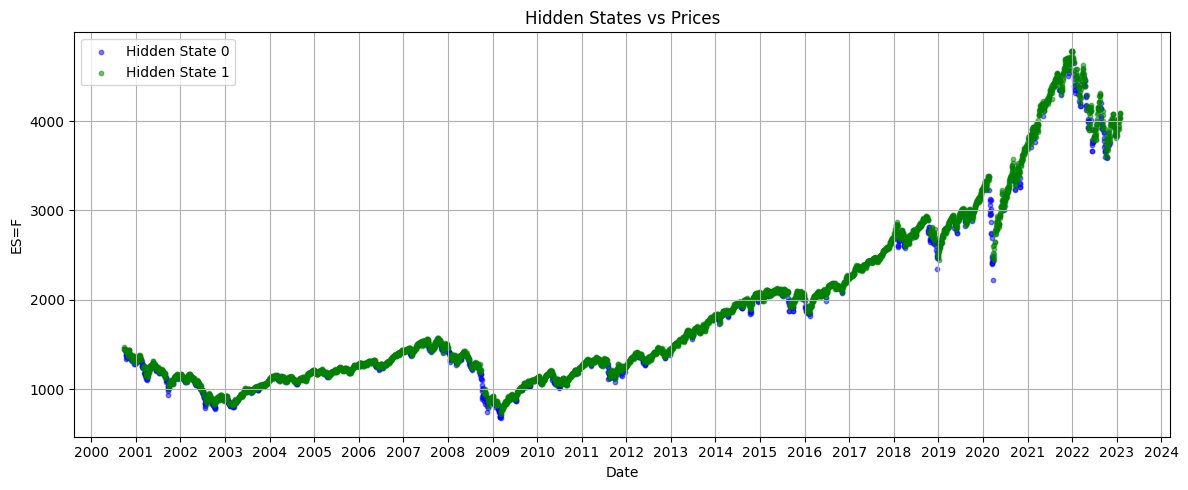

In [57]:
params = {
    'n_clusters': 2, 
    'linkage': 'complete',  
    'affinity': 'manhattan', 
    'metric': 'manhattan', 
    'random_state':100
}
clustering = regime_detection.get_regimes_clustering(params)
clustering_states = clustering.fit_predict(features)

plot_hidden_states(np.array(clustering_states), prices_clean[[f'{trading_instrument}']])

从上面的图表中我们可以看到，Agglomerative Clustering 能够检测到 Hidden State 1，这对应了分析期内的一些 Crashes。具体而言，它能够标记出金融危机和 COVID Shock。然而，值得强调的是，这种检测具有滞后性（Lagging），模型仅检测到了崩盘末期的观测值。此外，如果我们缩放到识别出的崩盘事件中的特定时段，会发现 Hidden State 1 非常稀疏，因为在同一时期内还识别出了多个 Hidden State 0。这些挑战将限制通过我们的 Agglomerative Clustering Model 获取的 Hidden State Predictions 在投资策略中的应用。

现在，让我们利用 GMM 模型，观察它识别 Market Regimes 的效果是否有所改善。我们使用自定义 Parameters 初始化模型，然后在图表中绘制预测的 Hidden States。这些 Parameters 是基于多次实验的最佳结果选出的。

Number of observations for State  0 : 446
Number of observations for State  1 : 5198


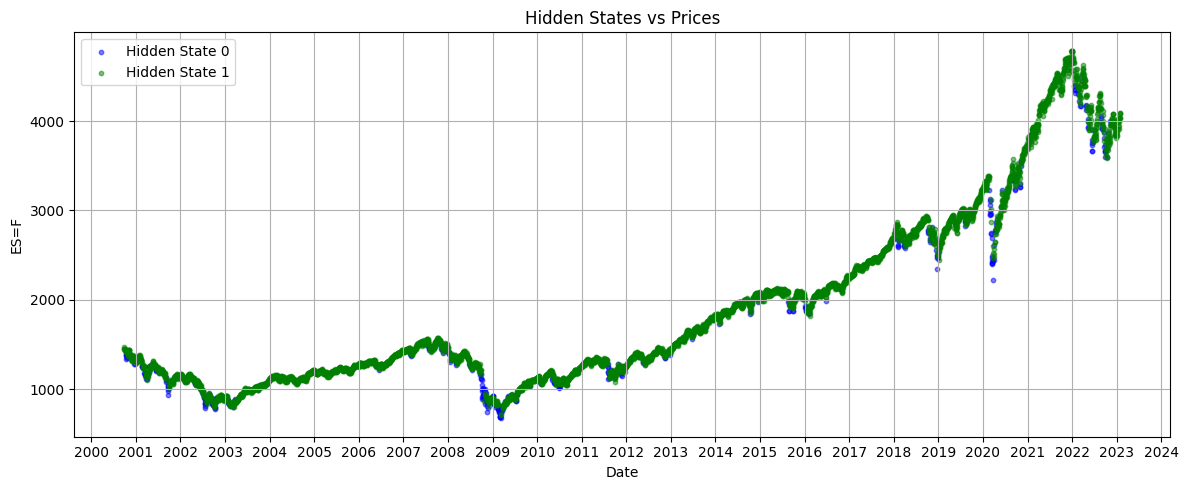

In [59]:
params = {'n_components':2, 'covariance_type': 'full', 'max_iter': 100000, 'n_init': 30,'init_params': 'kmeans', 'random_state':100}

gmm_model = regime_detection.get_regimes_gmm(features, params)
gmm_states = gmm_model.predict(features)
plot_hidden_states(np.array(gmm_states), prices_clean[[f'{trading_instrument}']])

上图展示了由 GMM 预测的 Hidden States 分布。该模型将 504 个观测值归类为 Hidden State 1，我们将其归因于 Crash Period（崩盘期）。与 Agglomerative Clustering 方法相比，我们可以看到 GMM 能够更好地识别 Market Regimes，且 Lags（滞后）更小。

尽管结果优于 Agglomerative Clustering，但此处的 Hidden State 1 依然相当稀疏。此外需要指出的是，这两项结果均来自 In-sample 测试，正如预期的那样，Out-of-sample 测试的结果可能会更差。

最后，现在让我们使用 HMM 来检测 Market Regimes，并将结果与前两种方法进行比较。我们使用自定义 Parameters 初始化模型，然后在图表中绘制预测的 Hidden States。这些 Parameters 同样是基于多次实验的最佳结果选出的。

Number of observations for State  0 : 713
Number of observations for State  1 : 4931


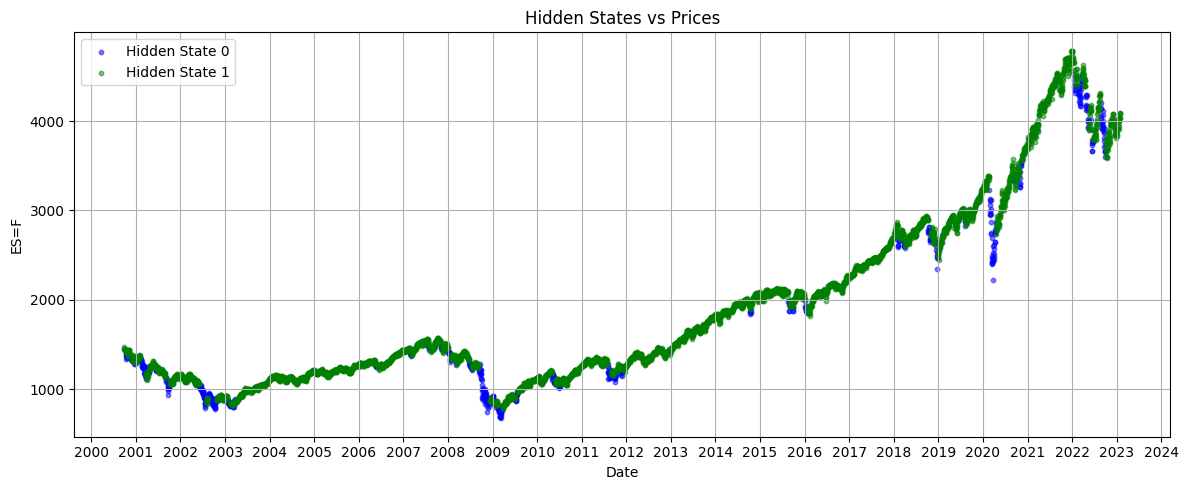

In [60]:
params = {'n_components':2, 'covariance_type':"full", 'random_state':100}

hmm_model = regime_detection.get_regimes_hmm(features, params)
hmm_states = hmm_model.predict(features)
plot_hidden_states(np.array(hmm_states), prices_clean[[f'{trading_instrument}']])

根据展示 HMM 预测结果的状态分布图，我们观察到了更好的分类效果（Segregation），至少与 Agglomerative Clustering 方法相比是如此。尽管整体图表与 GMM 的图表相似，但其状态的连续性（States Continuity）要稳定得多，这对于构建高效的投资策略至关重要。HMM 不仅能够识别出金融危机和 COVID 崩盘，还能（虽然带有一定滞后）识别出 2022 年 1 月之后开始的剧烈波动期。

再次强调，我们应当注意到，到目前为止本节中的所有分析均在 In-sample（样本内）进行，这会影响结果的 Robustness（稳健性）。在本文稍后的部分，我们将采用 Feed-forward training（前向训练）配合 Out-of-sample（样本外）测试，并基于这些结果构建我们的投资策略。

#### Feed-forward training and out of sample testing

考虑到 Agglomerative Clustering 的 In-sample 测试结果不足以作为投资策略的基础，我们针对 GMM 和 HMM 模型实现了 Feed-forward Training（前向训练）和 Out-of-sample（样本外）测试。为了实现 Feed-forward Training，我们定义了一个具有以下功能的函数：

1.在初始训练数据集上训练 HMM 或 GMM 模型。

2.预测下一个观测值的 State（状态）。

3.在指定的 Training Step（训练步长，即触发重新训练的观测值数量）之后重新训练模型。

下文我们实现了用于 Feed-forward Training 的函数。该函数接受模型、参数、收盘价、Splitting Index（分割索引）以及 Retraining Step Size（重训步长）作为输入变量，并返回 State Predictions（状态预测结果）。

In [64]:
def feed_forward_training(model, params, prices, start_pos, retrain_step):
    '''
    Input:
    model (<class 'method'>) - either gmm (Gaussian Mixture Models) or hmm (Hidden Markov Model)
    params (dict) - dictionary of parameters for a model
    prices (df) - Dataframe of close prices
    split_index (str) - index to split initial traing dataset and out of sample testing set
    retrain_step (int) - number of observations after which we retrain the model
    
    Output:
    states_pred (numpy.ndarray) - array of predicted hidden states
    '''
    rd_model = model(prices.iloc[:start_pos], params)
    states_pred = []
    
    # 3. 直接计算需要预测的总天数 (总长度 - 初始训练集长度)
    total_steps = len(prices) - start_pos
    
    # 用当前的索引位置作为累加器
    current_ptr = start_pos
    
    for i in range(total_steps):
        # 索引向后推移 1 天
        current_ptr += 1
        
        # 预测：只看截至目前的所有数据
        current_data = prices.iloc[:current_ptr]
        preds = rd_model.predict(current_data).tolist()
        states_pred.append(preds[-1])
        
        # 4. 触发重训
        if i % retrain_step == 0:
            rd_model = model(current_data, params)
            
    return states_pred

在运行该函数之前，让我们先指定模型、参数以及用于将数据集划分为初始训练集和样本外测试集的 Split Index（分割索引）。

需要注意的是，在本文范围内，我们使用的是与 In-sample 训练时相同的参数。因此，参数优化仍有提升空间，这可以通过将数据进一步划分为训练集、验证集和测试集，并执行 Grid Search（网格搜索）技术来实现。首先，让我们通过将日期分割为 2006-01-01 之前（初始训练集）和之后（测试集）来研究 GMM 的结果。

首先，让我们通过将日期分割为 2006-01-01 之前（初始训练集）和之后，来研究 GMM 的结果。

In [65]:
model_gmm =  regime_detection.get_regimes_gmm
params = {'n_components':2, 'covariance_type':"full", 'random_state':100, 'max_iter': 100000, 'n_init': 30,'init_params': 'kmeans', 'random_state':100}
split_index = np.where(prices_clean.index > '2006-01-01')[0][0]

在定义了参数、模型和分割索引之后，我们运行前向训练（feed-forward training）模型，设置每 20 个观测值（约一个交易月）重新训练一次，并绘制由 GMM 预测的隐状态（hidden states）图。

Number of observations for State  0 : 2677
Number of observations for State  1 : 1626


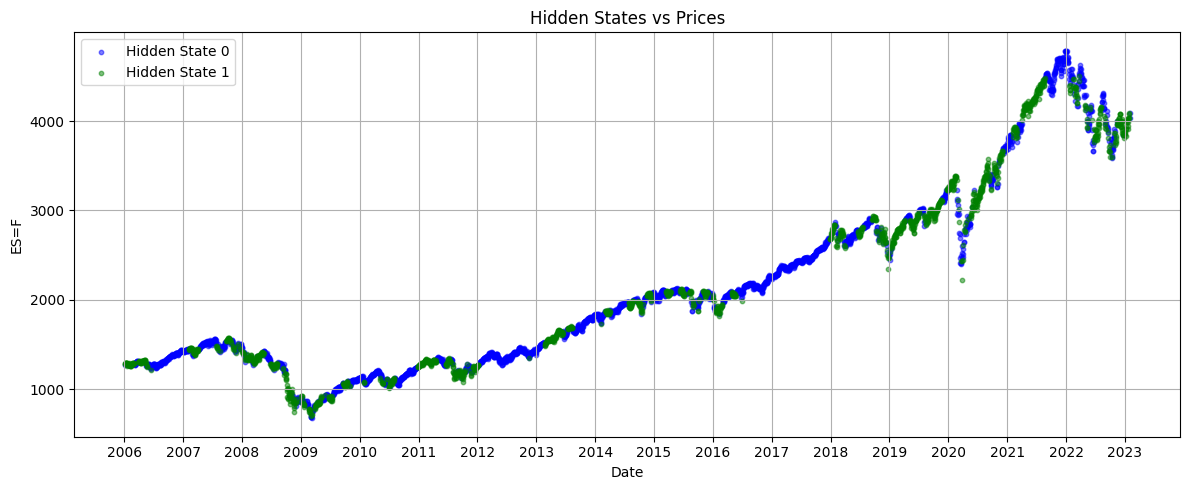

In [67]:
states_pred_gmm = feed_forward_training(model_gmm, params, features, split_index, 20)
plot_hidden_states(np.array(states_pred_gmm), prices_clean[[f'{trading_instrument}']][split_index:])

根据上图可以观察到，正如预期的那样，GMM 的样本外（Out-of-sample）测试结果比样本内（In-sample）结果要差得多。

具体而言，该模型在崩盘期间表现出的预测稳定性（Predictive Steadiness）较为一般。虽然模型能够识别出大部分的崩盘期，但它也将许多市场的上涨行情错误地标记为了“崩盘”，这种误判严重降低了它在构建投资策略时的实用价值。

现在，让我们使用相同的分割日期（Split Date）和重训步长（Retraining Step Size）来研究 HMM 的结果。同样地，HMM 的参数也沿用了样本内测试时的设置。下面我们定义参数，运行前向训练函数，并绘制预测的隐状态图。

In [69]:
model_hmm =  regime_detection.get_regimes_hmm
params = {'n_components':2, 'covariance_type': 'full', 'random_state':100}

Number of observations for State  0 : 325
Number of observations for State  1 : 3978


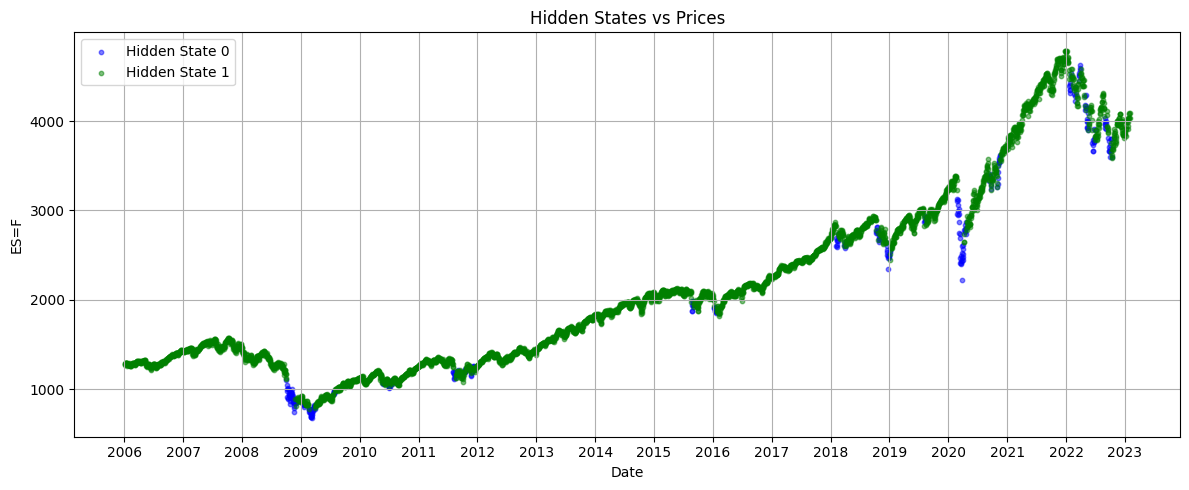

In [70]:
states_pred_hmm = feed_forward_training(model_hmm, params, features, split_index, 20)
plot_hidden_states(np.array(states_pred_hmm), prices_clean[[f'{trading_instrument}']][split_index:])

HMM 的结果要好得多，我们可以看到它清晰地标出了崩盘期，特别是金融危机和新冠疫情期间的崩盘。但在预测 2022 年以后开始的剧烈波动期时，模型的稳定性有所下降。

这可能是由于整体波动率体制（Volatility Regime）发生了变化：在上述两次崩盘中，市场出现了陡峭且长期的下跌；然而，2022 年后的“崩盘”包含了许多短期趋势和高波动时段。这一挑战可以通过调整模型参数、更换特征（例如采用不同周期的移动平均线）和/或更改重训周期来解决。不过，这些改进均超出了本文的讨论范围，可作为进一步研究和分析的课题。

此外，我们还构建了一个简单的投资策略，根据 HMM 预测出的状态输出进行多头（Long）和空头（Short）交易。

## Implementing an Investment Strategy

在本节中，我们基于预测的隐状态实现了一个简单的投资策略，其逻辑生成如下：

多头信号（Long signal）：当预期市场处于正常状态（Normal state）时。

空头信号（Short signal）：当市场处于崩盘或高波动状态（Crash or high volatility state）时。

在本文中，我们并未构建一个考虑交易手续费、滑点成本、追加保证金（Margin calls）等的端到端投资策略；相反，我们只是简单地根据价格变化和当天的活跃仓位来累计每日盈亏（P&L）。随后，我们将该策略的盈亏结果与基础的“买入持有”（Buy and Hold）策略进行对比。

作为第一步，让我们将每日收盘价与当天预测的状态进行合并。

In [71]:
prices_with_states = pd.DataFrame(prices_clean[split_index:][f'{trading_instrument}'])
prices_with_states['State'] = states_pred_hmm
prices_with_states.head()

,ES=F,State
Date,,
2006-01-03,1274.75,1
2006-01-04,1280.50,1
2006-01-05,1281.25,1
2006-01-06,1291.75,1
2006-01-09,1295.00,1


接下来，让我们计算收盘价的每日对数收益率（Log Returns）。

In [72]:
prices_with_states['P&L_daily'] = np.log(prices_with_states[trading_instrument] / prices_with_states[trading_instrument].shift(1)).dropna()
prices_with_states.head()

,ES=F,State,P&L_daily
Date,,,
2006-01-03,1274.75,1,NaN
2006-01-04,1280.50,1,0.004501
2006-01-05,1281.25,1,0.000586
2006-01-06,1291.75,1,0.008162
2006-01-09,1295.00,1,0.002513


由于我们是在市场收盘后预测当天的状态，为了避免前瞻偏差（Look-ahead Bias），我们将以当天的收盘价开仓或平仓，但累计的是次日的盈亏。为此，我们将预测的状态信号向后移动（Shift）一天。

In [73]:
prices_with_states['State'] = prices_with_states['State'].shift(1)
prices_with_states.dropna(inplace = True)

根据展示 HMM 预测状态分布的图表，正常状态（Normal state）被标记为 State 1，而高波动状态（High Volatility state）被标记为 State 0。

因此，当市场处于 State 1 时，我们将建立多头（Long）仓位；当市场处于 State 0 时，我们将进行做空（Short）。我们为仓位（Position）创建了一个新列，其中当状态为 1 时，仓位为 1；否则（即状态为 0 时），仓位为 -1。

In [74]:
prices_with_states['Position'] = np.where(prices_with_states['State'] == 1,1,-1)
prices_with_states.head()

,ES=F,State,P&L_daily,Position
Date,,,,
2006-01-04,1280.50,1.0,0.004501,1
2006-01-05,1281.25,1.0,0.000586,1
2006-01-06,1291.75,1.0,0.008162,1
2006-01-09,1295.00,1.0,0.002513,1
2006-01-10,1296.00,1.0,0.000772,1


现在，我们可以根据我们的仓位计算每日盈亏，并在整个期间内进行累计。

在下文中，我们通过将我们的仓位（多头为 1，空头为 -1）乘以每日盈亏，计算出每日策略结果（Daily Strategy Outcome）。随后，我们计算每日盈亏的累计和，以算出买入持有策略（Buy and Hold Strategy）的累计收益。同时，我们也累计各仓位的每日结果，以计算出基于 HMM 策略的累计收益。

In [75]:
prices_with_states['Daily_Outcome_hmm'] = prices_with_states['Position'] * prices_with_states['P&L_daily']
prices_with_states['Cumulative_Outcome_BaH'] = prices_with_states['P&L_daily'].cumsum()
prices_with_states['Cumulative_Outcome_hmm'] = prices_with_states['Daily_Outcome_hmm'].cumsum()
prices_with_states

,ES=F,State,P&L_daily,Position,Daily_Outcome_hmm,Cumulative_Outcome_BaH,Cumulative_Outcome_hmm
Date,,,,,,,
2006-01-04,1280.50,1.0,0.004501,1,0.004501,0.004501,0.004501
2006-01-05,1281.25,1.0,0.000586,1,0.000586,0.005086,0.005086
2006-01-06,1291.75,1.0,0.008162,1,0.008162,0.013248,0.013248
2006-01-09,1295.00,1.0,0.002513,1,0.002513,0.015761,0.015761
2006-01-10,1296.00,1.0,0.000772,1,0.000772,0.016533,0.016533
...,...,...,...,...,...,...,...
2023-01-25,4032.00,1.0,-0.000186,1,-0.000186,1.151512,1.204480
2023-01-26,4075.50,1.0,0.010731,1,0.010731,1.162243,1.215211
2023-01-27,4084.25,1.0,0.002145,1,0.002145,1.164388,1.217355


最后，我们将两种策略的累计收益（Cumulative Outcomes）绘制在同一张图中，以便对比两者的结果。

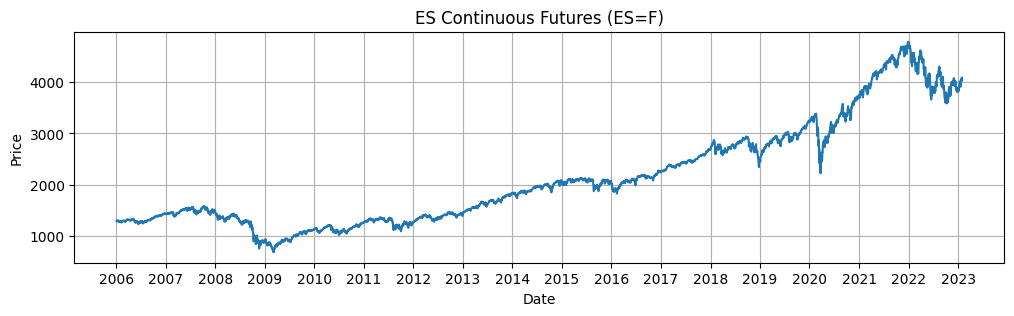

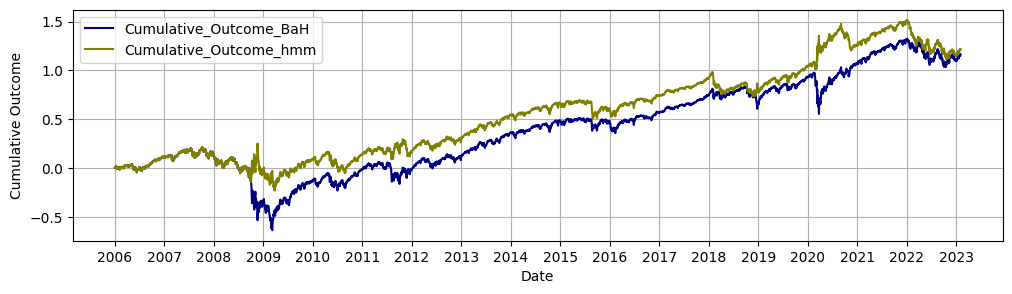

In [83]:
plt.figure(figsize=(12, 3))
plt.plot(prices_with_states.index, prices_with_states[trading_instrument])
plt.title("ES Continuous Futures (ES=F)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1)) 
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(prices_with_states.index, 
         prices_with_states["Cumulative_Outcome_BaH"], 
         label='Cumulative_Outcome_BaH', 
         color='navy', 
         linewidth=1.5)
plt.plot(prices_with_states.index, 
         prices_with_states['Cumulative_Outcome_hmm'], 
         label='Cumulative_Outcome_hmm', 
         color='olive', 
         linewidth=1.5)
plt.legend(loc='upper left', frameon=True)
plt.xlabel("Date")
plt.ylabel("Cumulative Outcome")
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1)) 
plt.show()

根据图表分析，基于 HMM 的策略表现优于基础的买入持有（Buy and Hold）策略。

在最初的约两年时间里，由于市场体制未发生变化，两种策略的行为基本一致，HMM 策略与买入持有策略的表现完全贴合。然而，在金融危机期间，随着市场体制发生转变，基于 HMM 的策略开始建立做空（Short sell）头寸并产生利润，而基础策略则遭受了损失。在整个分析期内，两种策略均持续积累利润，直到新冠疫情引发的崩盘（COVID crash）。在那段时期，HMM 策略不仅避开了崩盘，还通过建立做空头寸积累了一定利润，这种盈利态势一直持续到 2022 年初。

然而，此后由于体制转变识别的滞后性（Lagged behavior）以及状态预测的稀疏性（Scarcity），HMM 策略的利润有所下降。尽管出现了回落，但截至 2023 年 1 月，HMM 策略的表现依然优于基础策略。如前所述，滞后行为可以通过引入自适应重训机制（例如：调整重训周期、改变作为模型输入的移动平均线周期）来解决。为了应对稀疏性问题，可以引入体制转变确认机制。这为实验留下了广阔的空间，虽然这些内容超出了本文的讨论范围，但可作为未来研究的主题。

## Conclusion

在本文中，我们介绍了用于检测市场体制（Market Regimes）的几种统计和机器学习模型，并将其应用于标普 500 指数期货（S&P 500 futures）。通过开展样本内和样本外训练，我们发现隐马尔可夫模型（Hidden Markov Model, HMM）在识别市场体制转变方面表现最为出色。

此外，我们基于预测的状态构建了一个简单的投资策略。在 2006 年至 2023 年期间，该策略的表现优于基础的“买入持有”策略。需要特别说明的是，该策略并未考虑交易手续费和滑点成本（Slippage costs）等因素，而这些因素可能会影响实际结果。本文的主要目的并非提供一个可直接用于实战交易的模型，而是旨在演示各种市场体制检测方法，这些方法可以与更高级的投资策略相结合。

In [84]:
# 源代码请见 https://github.com/LSEG-API-Samples/Article.RD.Python.MarketRegimeDetectionUsingStatisticalAndMLBasedApproaches